In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# Sales Data Analysis Using Python

## Project Objective

Analyze sales data to identify trends, top-performing products, regional performance, category performance, and generate business insights.

## Project Workflow

1. Data Loading
2. Data Cleaning
3. Data Transformation
4. Exploratory Data Analysis
5. Visualization
6. Business Insights

## Load Dataset

In [2]:
df=pd.read_csv(r"C:\Users\yasht\Downloads\Sales Data analysis\sales_data.csv.csv")
df

,OrderID,OrderDate,Region,Salesperson,Category,Product,Units,UnitPrice,Revenue,CustomerType
0,ORD00001,06-09-2025,South,Meena,Grocery,Oil,37,1500.90,55533.30,Retail
1,ORD00002,21-12-2024,North,Arjun,Furniture,Table,32,354.18,11333.76,Wholesale
2,ORD00003,28-07-2024,West,Amit,Clothing,Shirt,29,962.81,27921.49,Wholesale
3,ORD00004,10-07-2024,South,Rahul,Furniture,Cabinet,11,226.02,2486.22,Retail
4,ORD00005,29-02-2024,East,Priya,Furniture,Cabinet,24,1957.12,46970.88,Retail
...,...,...,...,...,...,...,...,...,...,...
9995,ORD09996,28-06-2024,West,Arjun,Clothing,Jeans,16,1426.64,22826.24,Wholesale
9996,ORD09997,09-06-2024,East,Amit,Electronics,Monitor,38,994.26,37781.88,Wholesale
9997,ORD09998,28-03-2024,South,Divya,Clothing,Jacket,44,1859.11,81800.84,Retail
9998,ORD09999,19-07-2024,West,Karthik,Grocery,Milk,46,897.60,41289.60,Retail


## Dataset structure check


In [3]:
df.head(5)

,OrderID,OrderDate,Region,Salesperson,Category,Product,Units,UnitPrice,Revenue,CustomerType
0,ORD00001,06-09-2025,South,Meena,Grocery,Oil,37,1500.90,55533.30,Retail
1,ORD00002,21-12-2024,North,Arjun,Furniture,Table,32,354.18,11333.76,Wholesale
2,ORD00003,28-07-2024,West,Amit,Clothing,Shirt,29,962.81,27921.49,Wholesale
3,ORD00004,10-07-2024,South,Rahul,Furniture,Cabinet,11,226.02,2486.22,Retail
4,ORD00005,29-02-2024,East,Priya,Furniture,Cabinet,24,1957.12,46970.88,Retail


In [4]:
df.tail(5)

,OrderID,OrderDate,Region,Salesperson,Category,Product,Units,UnitPrice,Revenue,CustomerType
9995,ORD09996,28-06-2024,West,Arjun,Clothing,Jeans,16,1426.64,22826.24,Wholesale
9996,ORD09997,09-06-2024,East,Amit,Electronics,Monitor,38,994.26,37781.88,Wholesale
9997,ORD09998,28-03-2024,South,Divya,Clothing,Jacket,44,1859.11,81800.84,Retail
9998,ORD09999,19-07-2024,West,Karthik,Grocery,Milk,46,897.60,41289.60,Retail
9999,ORD10000,17-01-2025,East,Sneha,Electronics,Phone,48,1322.00,63456.00,Wholesale


In [5]:
df.shape

(10000, 10)

In [6]:
df.columns

Index(['OrderID', 'OrderDate', 'Region', 'Salesperson', 'Category', 'Product',
       'Units', 'UnitPrice', 'Revenue', 'CustomerType'],
      dtype='object')

In [7]:
df.dtypes

OrderID          object
OrderDate        object
Region           object
Salesperson      object
Category         object
Product          object
Units             int64
UnitPrice       float64
Revenue         float64
CustomerType     object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       10000 non-null  object 
 1   OrderDate     10000 non-null  object 
 2   Region        10000 non-null  object 
 3   Salesperson   10000 non-null  object 
 4   Category      10000 non-null  object 
 5   Product       10000 non-null  object 
 6   Units         10000 non-null  int64  
 7   UnitPrice     10000 non-null  float64
 8   Revenue       10000 non-null  float64
 9   CustomerType  10000 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 781.4+ KB


In [9]:
df.describe()

,Units,UnitPrice,Revenue
count,10000.000000,10000.000000,10000.000000
mean,25.652000,1008.288619,25818.527591
std,14.447961,575.149308,22255.298011
min,1.000000,10.090000,20.390000
25%,13.000000,510.617500,7452.920000
50%,26.000000,1006.385000,19419.960000
75%,38.000000,1500.832500,39522.110000
max,50.000000,1999.930000,99157.500000


Dataset Structure Check:

In this step, I loaded the sales dataset and checked the first few rows, last few rows, number of rows and columns, column names, data types, and summary statistics. This helps understand the dataset before cleaning and analysis.

## Data Cleaning

Check missing values

In [10]:
df.isnull().sum()

OrderID         0
OrderDate       0
Region          0
Salesperson     0
Category        0
Product         0
Units           0
UnitPrice       0
Revenue         0
CustomerType    0
dtype: int64

Missing Value Check:

I checked missing values column-wise to identify whether any data needs to be removed or filled before analysis.

Check duplicate records

In [11]:
df.duplicated().sum()

0

Duplicate Check:

I checked duplicate records to avoid repeated rows affecting revenue analysis and business insights.

Remove duplicates

In [12]:
df.drop_duplicates()

,OrderID,OrderDate,Region,Salesperson,Category,Product,Units,UnitPrice,Revenue,CustomerType
0,ORD00001,06-09-2025,South,Meena,Grocery,Oil,37,1500.90,55533.30,Retail
1,ORD00002,21-12-2024,North,Arjun,Furniture,Table,32,354.18,11333.76,Wholesale
2,ORD00003,28-07-2024,West,Amit,Clothing,Shirt,29,962.81,27921.49,Wholesale
3,ORD00004,10-07-2024,South,Rahul,Furniture,Cabinet,11,226.02,2486.22,Retail
4,ORD00005,29-02-2024,East,Priya,Furniture,Cabinet,24,1957.12,46970.88,Retail
...,...,...,...,...,...,...,...,...,...,...
9995,ORD09996,28-06-2024,West,Arjun,Clothing,Jeans,16,1426.64,22826.24,Wholesale
9996,ORD09997,09-06-2024,East,Amit,Electronics,Monitor,38,994.26,37781.88,Wholesale
9997,ORD09998,28-03-2024,South,Divya,Clothing,Jacket,44,1859.11,81800.84,Retail
9998,ORD09999,19-07-2024,West,Karthik,Grocery,Milk,46,897.60,41289.60,Retail


Standardize column names

In [13]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ","_")
df.columns = df.columns.str.lower()

Convert date column

In [14]:
df

,orderid,orderdate,region,salesperson,category,product,units,unitprice,revenue,customertype
0,ORD00001,06-09-2025,South,Meena,Grocery,Oil,37,1500.90,55533.30,Retail
1,ORD00002,21-12-2024,North,Arjun,Furniture,Table,32,354.18,11333.76,Wholesale
2,ORD00003,28-07-2024,West,Amit,Clothing,Shirt,29,962.81,27921.49,Wholesale
3,ORD00004,10-07-2024,South,Rahul,Furniture,Cabinet,11,226.02,2486.22,Retail
4,ORD00005,29-02-2024,East,Priya,Furniture,Cabinet,24,1957.12,46970.88,Retail
...,...,...,...,...,...,...,...,...,...,...
9995,ORD09996,28-06-2024,West,Arjun,Clothing,Jeans,16,1426.64,22826.24,Wholesale
9996,ORD09997,09-06-2024,East,Amit,Electronics,Monitor,38,994.26,37781.88,Wholesale
9997,ORD09998,28-03-2024,South,Divya,Clothing,Jacket,44,1859.11,81800.84,Retail
9998,ORD09999,19-07-2024,West,Karthik,Grocery,Milk,46,897.60,41289.60,Retail


In [15]:
# Convert orderdate column into proper datetime format
df["orderdate"] = pd.to_datetime(
    df["orderdate"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Check converted date column
print(df["orderdate"].head())

# Check if any dates failed to convert
print("Invalid dates:", df["orderdate"].isnull().sum())

0   2025-09-06
1   2024-12-21
2   2024-07-28
3   2024-07-10
4   2024-02-29
Name: orderdate, dtype: datetime64[ns]
Invalid dates: 0


In [16]:
df["month"] = df["orderdate"].dt.month

Convert revenue column

In [17]:
df["revenue"] = df["revenue"].astype(float)

revenue category column

In [18]:
def revenue_category(value):
    if value >= 50000:
        return "High Revenue"
    elif value >= 30000:
        return "Medium Revenue"
    else:
        return "Low Revenue"

df["revenue_category"] = df["revenue"].apply(revenue_category)

Check cleaned data

In [19]:
df.head(5)


,orderid,orderdate,region,salesperson,category,product,units,unitprice,revenue,customertype,month,revenue_category
0,ORD00001,2025-09-06,South,Meena,Grocery,Oil,37,1500.90,55533.30,Retail,9,High Revenue
1,ORD00002,2024-12-21,North,Arjun,Furniture,Table,32,354.18,11333.76,Wholesale,12,Low Revenue
2,ORD00003,2024-07-28,West,Amit,Clothing,Shirt,29,962.81,27921.49,Wholesale,7,Low Revenue
3,ORD00004,2024-07-10,South,Rahul,Furniture,Cabinet,11,226.02,2486.22,Retail,7,Low Revenue
4,ORD00005,2024-02-29,East,Priya,Furniture,Cabinet,24,1957.12,46970.88,Retail,2,Medium Revenue


In [20]:
df.tail(5)

,orderid,orderdate,region,salesperson,category,product,units,unitprice,revenue,customertype,month,revenue_category
9995,ORD09996,2024-06-28,West,Arjun,Clothing,Jeans,16,1426.64,22826.24,Wholesale,6,Low Revenue
9996,ORD09997,2024-06-09,East,Amit,Electronics,Monitor,38,994.26,37781.88,Wholesale,6,Medium Revenue
9997,ORD09998,2024-03-28,South,Divya,Clothing,Jacket,44,1859.11,81800.84,Retail,3,High Revenue
9998,ORD09999,2024-07-19,West,Karthik,Grocery,Milk,46,897.60,41289.60,Retail,7,Medium Revenue
9999,ORD10000,2025-01-17,East,Sneha,Electronics,Phone,48,1322.00,63456.00,Wholesale,1,High Revenue


Save cleaned dataset

In [21]:
df.to_csv("cleaned_sales_data.csv", index=False)

Data Cleaning Summary:

In this step, I checked missing values, removed duplicate records, standardized column names, converted the date column into datetime format, converted revenue into numeric format, and created new columns such as month and revenue category.

## Data Transformation



load cleaned dataset

In [22]:
import pandas as pd

df = pd.read_csv("cleaned_sales_data.csv")

In [23]:
df[["orderdate", "month", "revenue", "revenue_category"]].head()

,orderdate,month,revenue,revenue_category
0,2025-09-06,9,55533.30,High Revenue
1,2024-12-21,12,11333.76,Low Revenue
2,2024-07-28,7,27921.49,Low Revenue
3,2024-07-10,7,2486.22,Low Revenue
4,2024-02-29,2,46970.88,Medium Revenue


In this step, I created new columns from the cleaned dataset. I extracted the month from the order date for monthly trend analysis and created a revenue category column to classify revenue values.

## Revenue Analysis

In [24]:
total_revenue = df["revenue"].sum()
Highest_revenue = df["revenue"].max()
lowest_revenue = df["revenue"].min()
average_revenue = df["revenue"].mean()

print("Total_Revenue:", total_revenue)
print("Highest_Revenue:", Highest_revenue)
print("Lowest_Revenue:", lowest_revenue)
print("Average_Revenue:", average_revenue)


Total_Revenue: 258185275.91
Highest_Revenue: 99157.5
Lowest_Revenue: 20.39
Average_Revenue: 25818.527591


In this section, I analyzed overall revenue by calculating total revenue, average revenue, highest revenue, and lowest revenue.

## Category Analysis

In [25]:
category_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
print(category_revenue)

category
Grocery        65481161.38
Electronics    64605587.49
Furniture      64088311.18
Clothing       64010215.86
Name: revenue, dtype: float64


In this section, I analyzed revenue by product category to identify which category contributed the most to total sales.

## Region Analysis

In [26]:
region_revenue = df.groupby("region")["revenue"].sum().sort_values(ascending=False)
print(region_revenue)

region
South    65433287.82
West     65216214.11
East     64020176.38
North    63515597.60
Name: revenue, dtype: float64


## Product Analysis

In [27]:
top_5_products = df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(5)
print(top_5_products)

product
Phone      16933817.98
Cabinet    16932564.38
Milk       16884429.31
Shirt      16829612.87
Shoes      16492094.33
Name: revenue, dtype: float64


In this section, I identified the top 5 products based on revenue.

## Monthly Trend Analysis

In [28]:
monthly_revenue = df.groupby("month")["revenue"].sum()
print(monthly_revenue)

month
1     22720894.21
2     21615413.89
3     21253355.59
4     22157223.04
5     22102589.04
6     22102115.51
7     22092173.68
8     22085332.09
9     20782246.38
10    19124104.99
11    21540838.44
12    20608989.05
Name: revenue, dtype: float64


In this section, I analyzed monthly revenue to identify peak and low-performing sales periods.

## Visualization

Revenue by Region — Matplotlib

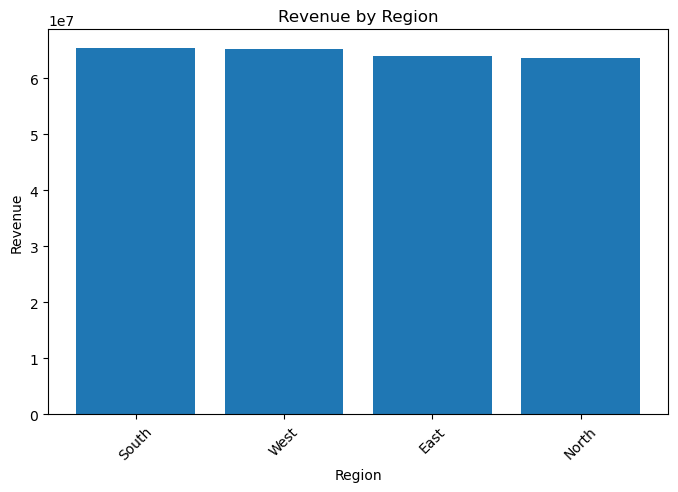

In [32]:
region_revenue = df.groupby("region")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(region_revenue.index, region_revenue.values)
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

This chart shows revenue performance across different regions.

Revenue by Category — Seaborn

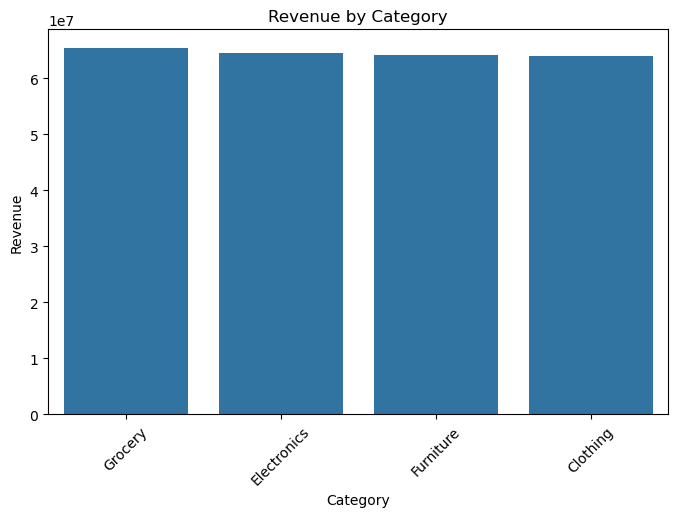

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

category_revenue = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue,
    x="category",
    y="revenue"
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

This chart shows which product category contributes the highest revenue.

Monthly Revenue Trend — Matplotlib

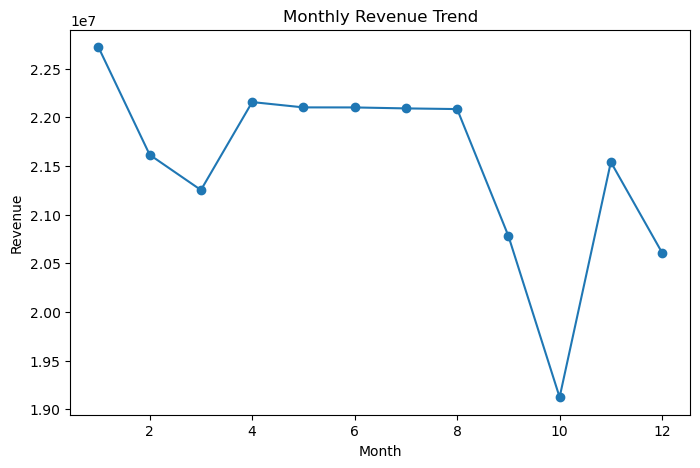

In [38]:
monthly_revenue = df.groupby("month")["revenue"].sum()

plt.figure(figsize=(8,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

This line chart shows revenue movement across months.

Revenue Share by Category — Plotly

In [40]:
import plotly.express as px

category_revenue = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.pie(
    category_revenue,
    names="category",
    values="revenue",
    title="Revenue Share by Category"
)

fig.show()

This interactive pie chart shows the revenue share of each product category.

Top 5 Products — Matplotlib

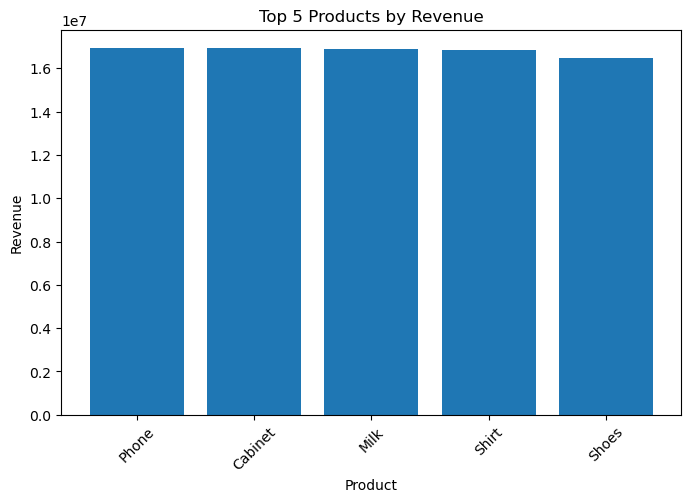

In [41]:
top_5_products = (
    df.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))

plt.bar(
    top_5_products.index,
    top_5_products.values
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

This chart highlights the top 5 revenue-generating products.

## Business Insights

1. The highest revenue-generating region is south, which shows strong sales performance in that area.

2. The highest revenue-generating category is Electronics, which means this category contributes more to overall sales.

3. The top-performing product is Phone, so this product can be focused for promotion or stock planning.

4. The highest revenue month is February, which shows the peak sales period.

5. The lowest revenue month is april, which may need further analysis to understand low performance.

## Conclusion

This project analyzed sales data using Python. I used Pandas for data cleaning, transformation, and analysis. I created revenue, category, region, product, and monthly trend analysis. I also used Matplotlib, Seaborn, and Plotly to visualize the results. The project helped identify top-performing regions, categories, products, and sales trends.